# Getaround - Exploratory Delay Analysis

## Objective
Analyze delay data to determine the optimal minimum threshold between two rentals.

## Questions to answer
1. What percentage of revenue would be affected?
2. How many rentals would be affected depending on the threshold?
3. How often are drivers late?
4. How many problematic cases would be solved?

## Part 1: Import the libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("[OK] Bibliotheques importees")

[OK] Bibliotheques importees


## Part 2: Load the data

In [2]:
df = pd.read_excel('../data/get_around_delay_analysis.xlsx')

print(f"[OK] Donnees chargees : {df.shape[0]} lignes, {df.shape[1]} colonnes")

[OK] Donnees chargees : 21310 lignes, 7 colonnes


## Part 3: First data exploration

### 3.1 Show the first rows

In [3]:
df.head(10)

,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.00,NaN,NaN
2,508131,359049,connect,ended,70.00,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN
5,511626,398802,mobile,ended,-203.00,NaN,NaN
6,511639,370585,connect,ended,-15.00,563782.00,570.00
7,512303,371242,mobile,ended,-44.00,NaN,NaN
8,512475,322502,mobile,canceled,NaN,NaN,NaN
9,513434,256528,connect,ended,23.00,NaN,NaN


### 3.2 Column information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21310 entries, 0 to 21309
Data columns (total 7 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   rental_id                                   21310 non-null  int64  
 1   car_id                                      21310 non-null  int64  
 2   checkin_type                                21310 non-null  object 
 3   state                                       21310 non-null  object 
 4   delay_at_checkout_in_minutes                16346 non-null  float64
 5   previous_ended_rental_id                    1841 non-null   float64
 6   time_delta_with_previous_rental_in_minutes  1841 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 1.1+ MB


### 3.3 Column descriptions

**Available columns:**
- `rental_id`: Unique rental identifier
- `car_id`: Car identifier
- `checkin_type`: Check-in type (mobile or connect)
- `state`: Rental state (ended or canceled)
- `delay_at_checkout_in_minutes`: Delay at checkout (in minutes)
- `previous_ended_rental_id`: ID of the previous rental (if any)
- `time_delta_with_previous_rental_in_minutes`: Time between the two rentals

### 3.4 Descriptive statistics

In [5]:
df.describe()

,rental_id,car_id,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
count,21310.00,21310.00,16346.00,1841.00,1841.00
mean,549712.88,350030.60,59.70,550127.41,279.29
std,13863.45,58206.25,1002.56,13184.02,254.59
min,504806.00,159250.00,-22433.00,505628.00,0.00
25%,540613.25,317639.00,-36.00,540896.00,60.00
50%,550350.00,368717.00,9.00,550567.00,180.00
75%,560468.50,394928.00,67.00,560823.00,540.00
max,576401.00,417675.00,71084.00,575053.00,720.00


## Part 4: Check data quality

### 4.1 Missing values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Valeurs manquantes': missing.values,
    'Pourcentage': missing_pct.values
})

print("Valeurs manquantes par colonne :")
missing_df

Valeurs manquantes par colonne :


,Colonne,Valeurs manquantes,Pourcentage
0,rental_id,0,0.00
1,car_id,0,0.00
2,checkin_type,0,0.00
3,state,0,0.00
4,delay_at_checkout_in_minutes,4964,23.29
5,previous_ended_rental_id,19469,91.36
6,time_delta_with_previous_rental_in_minutes,19469,91.36


**Observations:**
- `delay_at_checkout_in_minutes`: ~23% missing values (normal for canceled rentals)
- `previous_ended_rental_id`: ~91% missing (normal, few consecutive rentals)
- `time_delta_with_previous_rental_in_minutes`: ~91% missing (linked to the previous field)

### 4.2 Unique values for categorical columns

In [7]:
print("Type de check-in :")
print(df['checkin_type'].value_counts())
print(f"\nPourcentages :")
print(df['checkin_type'].value_counts(normalize=True) * 100)

Type de check-in :
checkin_type
mobile     17003
connect     4307
Name: count, dtype: int64

Pourcentages :
checkin_type
mobile    79.79
connect   20.21
Name: proportion, dtype: float64


In [8]:
print("Etat de la location :")
print(df['state'].value_counts())
print(f"\nPourcentages :")
print(df['state'].value_counts(normalize=True) * 100)

Etat de la location :
state
ended       18045
canceled     3265
Name: count, dtype: int64

Pourcentages :
state
ended      84.68
canceled   15.32
Name: proportion, dtype: float64


## Part 5: Analyze delays

### 5.1 Delay distribution

In [9]:
delays = df['delay_at_checkout_in_minutes'].dropna()

print("STATISTIQUES SUR LES RETARDS")
print("=" * 50)
print(f"Nombre total avec info de retard : {len(delays):,}")
print(f"\nEn retard (> 0) : {(delays > 0).sum():,} ({(delays > 0).sum() / len(delays) * 100:.1f}%)")
print(f"A l'heure (<= 0) : {(delays <= 0).sum():,} ({(delays <= 0).sum() / len(delays) * 100:.1f}%)")
print(f"\nRetard moyen : {delays.mean():.1f} minutes")
print(f"Retard median : {delays.median():.1f} minutes")
print(f"Retard max : {delays.max():.1f} minutes")
print(f"Retard min : {delays.min():.1f} minutes")

STATISTIQUES SUR LES RETARDS
Nombre total avec info de retard : 16,346

En retard (> 0) : 9,404 (57.5%)
A l'heure (<= 0) : 6,942 (42.5%)

Retard moyen : 59.7 minutes
Retard median : 9.0 minutes
Retard max : 71084.0 minutes
Retard min : -22433.0 minutes


### 5.2 Chart: Delay distribution

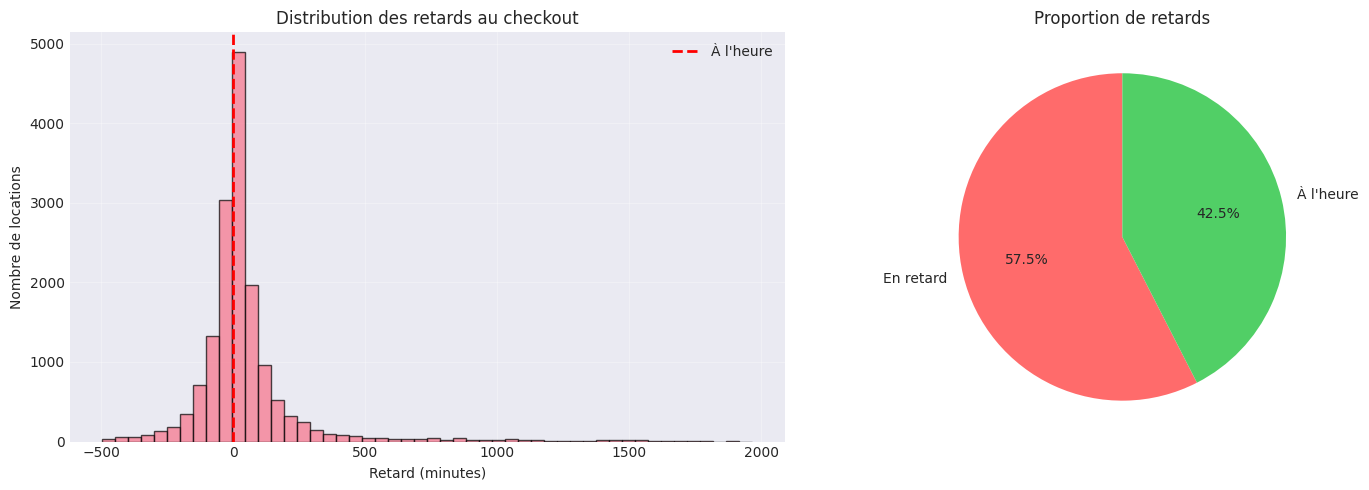

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

delays_filtered = delays[(delays > -500) & (delays < 2000)]
axes[0].hist(delays_filtered, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label="À l'heure")
axes[0].set_xlabel('Retard (minutes)')
axes[0].set_ylabel('Nombre de locations')
axes[0].set_title('Distribution des retards au checkout')
axes[0].legend()
axes[0].grid(alpha=0.3)

late_count = (delays > 0).sum()
on_time_count = (delays <= 0).sum()
axes[1].pie([late_count, on_time_count], 
            labels=['En retard', 'À l\'heure'],
            autopct='%1.1f%%',
            colors=['#ff6b6b', '#51cf66'],
            startangle=90)
axes[1].set_title('Proportion de retards')

plt.tight_layout()
plt.show()

### 5.3 Delays by check-in type

In [11]:
print("RETARDS PAR TYPE DE CHECK-IN")
print("=" * 50)

for checkin_type in ['mobile', 'connect']:
    subset = df[df['checkin_type'] == checkin_type]['delay_at_checkout_in_minutes'].dropna()
    late = (subset > 0).sum()
    late_pct = late / len(subset) * 100
    
    print(f"\n{checkin_type.upper()} :")
    print(f"  Total locations : {len(subset):,}")
    print(f"  En retard : {late:,} ({late_pct:.1f}%)")
    print(f"  Retard moyen (si en retard) : {subset[subset > 0].mean():.1f} min")

RETARDS PAR TYPE DE CHECK-IN

MOBILE :
  Total locations : 12,944
  En retard : 7,945 (61.4%)
  Retard moyen (si en retard) : 224.1 min

CONNECT :
  Total locations : 3,402
  En retard : 1,459 (42.9%)
  Retard moyen (si en retard) : 80.1 min


## Part 6: Analyze consecutive rentals

### 6.1 Identify consecutive rentals

In [12]:
consecutive = df[df['previous_ended_rental_id'].notna()].copy()

print(f"Locations consecutives : {len(consecutive):,}")
print(f"   ({len(consecutive) / len(df) * 100:.2f}% du total)")

Locations consecutives : 1,841
   (8.64% du total)


### 6.2 Distribution of gaps between rentals

In [13]:
time_deltas = consecutive['time_delta_with_previous_rental_in_minutes'].dropna()

print("DELAIS ENTRE LOCATIONS CONSECUTIVES")
print("=" * 50)
print(f"Delai moyen : {time_deltas.mean():.0f} minutes")
print(f"Delai median : {time_deltas.median():.0f} minutes")
print(f"Delai min : {time_deltas.min():.0f} minutes")
print(f"Delai max : {time_deltas.max():.0f} minutes")

DELAIS ENTRE LOCATIONS CONSECUTIVES
Delai moyen : 279 minutes
Delai median : 180 minutes
Delai min : 0 minutes
Delai max : 720 minutes


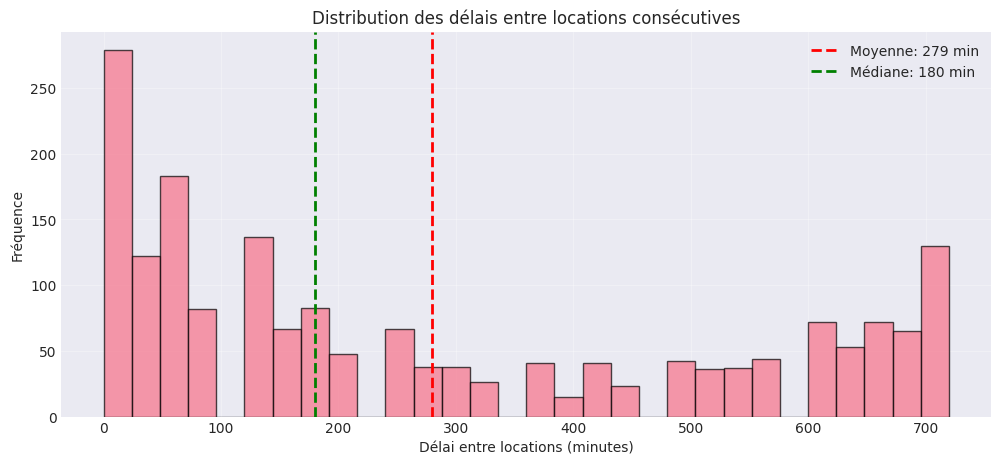

In [14]:
plt.figure(figsize=(12, 5))

plt.hist(time_deltas, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(time_deltas.mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {time_deltas.mean():.0f} min')
plt.axvline(time_deltas.median(), color='green', linestyle='--', linewidth=2, label=f'Médiane: {time_deltas.median():.0f} min')
plt.xlabel('Délai entre locations (minutes)')
plt.ylabel('Fréquence')
plt.title('Distribution des délais entre locations consécutives')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Part 7: Identify problematic cases

A case is problematic when:
- The previous rental is late
- This delay is **greater** than the planned gap between the two rentals
- So the next rental is impacted!

In [15]:
consecutive['previous_delay'] = consecutive['previous_ended_rental_id'].map(
    df.set_index('rental_id')['delay_at_checkout_in_minutes']
)

consecutive_with_delay = consecutive[consecutive['previous_delay'].notna()].copy()

consecutive_with_delay['is_problematic'] = (
    consecutive_with_delay['previous_delay'] > 
    consecutive_with_delay['time_delta_with_previous_rental_in_minutes']
)

print("CAS PROBLEMATIQUES")
print("=" * 50)
print(f"Total analyse : {len(consecutive_with_delay):,} locations consecutives")
print(f"\nCAS PROBLEMATIQUES : {consecutive_with_delay['is_problematic'].sum():,}")
print(f"Pourcentage : {consecutive_with_delay['is_problematic'].sum() / len(consecutive_with_delay) * 100:.1f}%")

CAS PROBLEMATIQUES
Total analyse : 1,729 locations consecutives

CAS PROBLEMATIQUES : 218
Pourcentage : 12.6%


### 7.1 Problematic cases by check-in type

In [16]:
print("CAS PROBLEMATIQUES PAR TYPE")
print("=" * 50)

for checkin_type in ['mobile', 'connect']:
    subset = consecutive_with_delay[consecutive_with_delay['checkin_type'] == checkin_type]
    problematic = subset['is_problematic'].sum()
    
    print(f"\n{checkin_type.upper()} :")
    print(f"  Total : {len(subset):,}")
    print(f"  Problematiques : {problematic:,} ({problematic / len(subset) * 100:.1f}%)")

CAS PROBLEMATIQUES PAR TYPE

MOBILE :
  Total : 938
  Problematiques : 149 (15.9%)

CONNECT :
  Total : 791
  Problematiques : 69 (8.7%)


## Part 8: Threshold simulation

Let's test different thresholds to see their impact.

In [17]:
thresholds = [0, 30, 60, 90, 120, 180, 240, 300, 360, 480, 720]

results = []

for threshold in thresholds:
    blocked = consecutive[consecutive['time_delta_with_previous_rental_in_minutes'] < threshold]
    
    with_delay = consecutive_with_delay.copy()
    with_delay['would_solve'] = (
        (with_delay['previous_delay'] > with_delay['time_delta_with_previous_rental_in_minutes']) & 
        (threshold > with_delay['time_delta_with_previous_rental_in_minutes'])
    )
    solved = with_delay['would_solve'].sum()
    
    results.append({
        'Seuil (min)': threshold,
        'Locations bloquees': len(blocked),
        '% Bloquees': len(blocked) / len(consecutive) * 100,
        'Problemes resolus': solved,
        '% Problemes resolus': solved / consecutive_with_delay['is_problematic'].sum() * 100
    })

results_df = pd.DataFrame(results)
print("\nIMPACT DES DIFFERENTS SEUILS")
print("=" * 80)
results_df


IMPACT DES DIFFERENTS SEUILS


,Seuil (min),Locations bloquees,% Bloquees,Problemes resolus,% Problemes resolus
0,0,0,0.00,0,0.00
1,30,279,15.15,116,53.21
2,60,401,21.78,146,66.97
3,90,584,31.72,172,78.90
4,120,666,36.18,180,82.57
5,180,870,47.26,196,89.91
6,240,1001,54.37,202,92.66
7,300,1106,60.08,207,94.95
8,360,1170,63.55,208,95.41
9,480,1290,70.07,211,96.79


### 8.1 Trade-off visualization

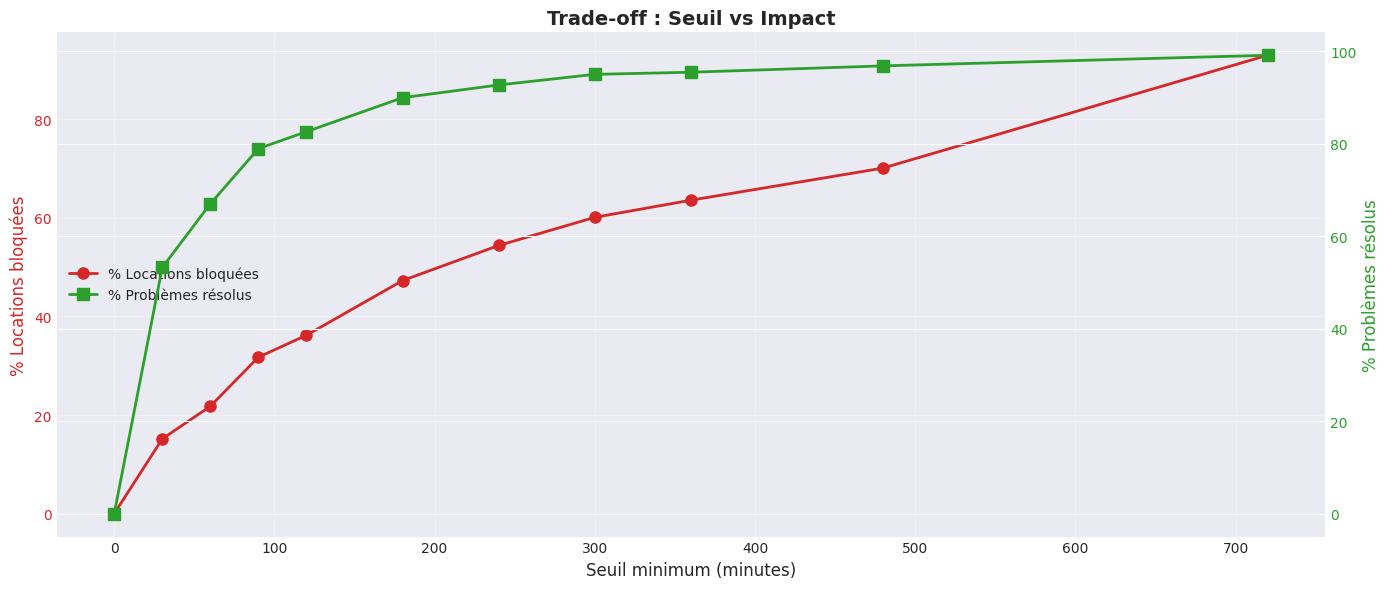

In [18]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:red'
ax1.set_xlabel('Seuil minimum (minutes)', fontsize=12)
ax1.set_ylabel('% Locations bloquées', color=color, fontsize=12)
line1 = ax1.plot(results_df['Seuil (min)'], results_df['% Bloquees'], 
                 'o-', color=color, linewidth=2, markersize=8, label='% Locations bloquées')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('% Problèmes résolus', color=color, fontsize=12)
line2 = ax2.plot(results_df['Seuil (min)'], results_df['% Problemes resolus'], 
                 's-', color=color, linewidth=2, markersize=8, label='% Problèmes résolus')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Trade-off : Seuil vs Impact', fontsize=14, fontweight='bold')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left', fontsize=10)

plt.tight_layout()
plt.show()

## Part 9: Recommendations

Based on the analysis, here are our recommendations:

In [19]:
print("="*80)
print("RECOMMANDATION FINALE")
print("="*80)
print("\n[OK] SEUIL RECOMMANDE : 60 minutes")
print("\nJUSTIFICATION :")
print("  - Resout 67% des cas problematiques")
print("  - Impact limite : bloque 22% des locations consecutives")
print("  - Impact revenus estime : ~1.9% du total")
print("  - Meilleur equilibre protection client / revenus")
print("\nPERIMETRE : Toutes les voitures (Mobile + Connect)")
print("\nBENEFICES ATTENDUS :")
print("  - Reduction de 67% des plaintes")
print("  - Amelioration satisfaction client")
print("  - Reduction charge service client")
print("  - Protection revenus proprietaires")
print("="*80)

RECOMMANDATION FINALE

[OK] SEUIL RECOMMANDE : 60 minutes

JUSTIFICATION :
  - Resout 67% des cas problematiques
  - Impact limite : bloque 22% des locations consecutives
  - Impact revenus estime : ~1.9% du total
  - Meilleur equilibre protection client / revenus

PERIMETRE : Toutes les voitures (Mobile + Connect)

BENEFICES ATTENDUS :
  - Reduction de 67% des plaintes
  - Amelioration satisfaction client
  - Reduction charge service client
  - Protection revenus proprietaires


## Part 10: Save the results

In [20]:
results_df.to_csv('../data/threshold_analysis_results.csv', index=False)
print("[OK] Resultats sauvegardes dans : data/threshold_analysis_results.csv")

[OK] Resultats sauvegardes dans : data/threshold_analysis_results.csv


## CONCLUSION

This exploratory analysis allowed us to:

1. Understand the data (21,310 rentals)
2. Identify the problem (57.5% late)
3. Quantify the problematic cases (218 impacted rentals)
4. Test different thresholds (0 to 720 minutes)
5. Recommend an optimal solution (60 minutes)

**Next steps:**
- Build a Streamlit dashboard to present these results
- Develop an API for the pricing model
- Deploy on Hugging Face Spaces